# **Deep Learning - Klassificera ansiktsuttryck med neurala nätverk**

I denna notebook använder jag neurala nätverk för att bygga en modell som kan klassificera ansiktsuttryck från bilder.

Struktur:

- Läs in data
- Undersök data
- Förbered data
- Bygg en modell
- Träna modellen
- Utvärdera modellerna
- Gör prediktioner på ny data
- Analys 
- Reflektion

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import seaborn as sns

tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


## **1. Läs in data**

Delar upp train och test bilderna i variablerna: train_dataset, val_dataset och test_dataset.

In [44]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "train",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(48,48),
    color_mode="grayscale",
    batch_size=32,
    shuffle=True
)


val_dataset = tf.keras.utils.image_dataset_from_directory(
    "train",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(48,48),
    color_mode="grayscale",
    batch_size=32
)


test_dataset = tf.keras.utils.image_dataset_from_directory(
    "test",
    image_size=(48,48),
    color_mode="grayscale",
    batch_size=32,
    shuffle=False
)

CLASS_NAMES = train_dataset.class_names
NUM_CLASSES = len(CLASS_NAMES)
test_class_names = test_dataset.class_names

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.
Found 7178 files belonging to 7 classes.


- train innehåller 28709 bilder, som hör till 7 klasser. Av dessa används 22968 till träning, 5741 till validation. 
- test innehåller 7178 bilder som tillhör 7 klasser.

## **2. Undersök data**

In [45]:
print(train_dataset.class_names)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [46]:
import os

train_path = "train"
class_counts = {}

print("<<< TRÄNINGSDATA >>>\n")

for class_name in os.listdir(train_path):
    class_path = os.path.join(train_path, class_name)
    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        class_counts[class_name] = num_images
        print(f"{class_name}: {num_images} bilder")


test_path = "test"

print("\n\n<<< TESTDATA >>>\n")

for class_name in os.listdir(test_path):
    class_path = os.path.join(test_path, class_name)
    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        print(f"{class_name}: {num_images} bilder")

<<< TRÄNINGSDATA >>>

angry: 3995 bilder
disgust: 436 bilder
fear: 4097 bilder
happy: 7215 bilder
neutral: 4965 bilder
sad: 4830 bilder
surprise: 3171 bilder


<<< TESTDATA >>>

angry: 958 bilder
disgust: 111 bilder
fear: 1024 bilder
happy: 1774 bilder
neutral: 1233 bilder
sad: 1247 bilder
surprise: 831 bilder


Här är en lista över hur många bilder som finns i varje klass, där varje klass representerar ett ansiktsuttryck.

Klasserna är: angry, disgust, fear, happy, neutral, sad och surprise.

#### **Visuell klassfördelning**

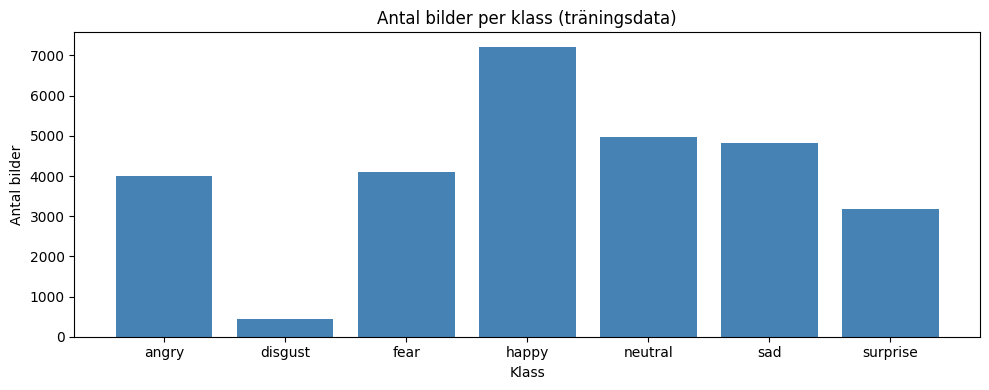

In [47]:
# Visualisera klassfördelning
plt.figure(figsize=(10, 4))
plt.bar(class_counts.keys(), class_counts.values(), color='steelblue')
plt.title('Antal bilder per klass (träningsdata)')
plt.xlabel('Klass')
plt.ylabel('Antal bilder')
plt.tight_layout()
plt.show()

En graf som visar fördelningen av antalet bilder per klass för träningsdatan. Som man kan se så har 'happy' flest bilder, de andra klasserna är rätt jämna i antal, förutom 'disgust' som har väldigt få bilder. Detta kan påverka modellens resultat då den får mer träningsdata för vissa klasser än andra. 

### **Exempelbilder från träningsdatasetet**
- Några bilder för att få en bättre överblick av datasetet.

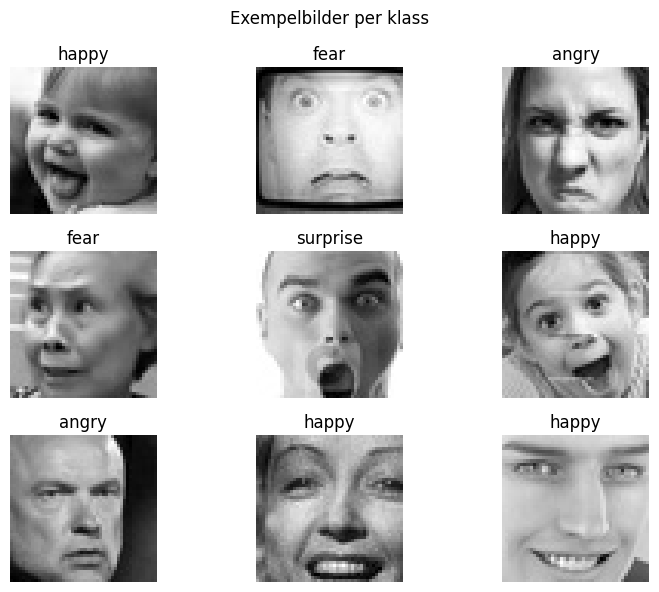

In [49]:
plt.figure(figsize=(8, 6))
for images, labels in train_dataset.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"), cmap="gray")
    plt.title(CLASS_NAMES[labels[i]])
    plt.axis("off")

plt.suptitle("Exempelbilder per klass")
plt.tight_layout()
plt.show() 

## **3. Förbered datan**

Jag börjar med att normalisera bilderna, detta för att göra träningen stabilare. Pixelvärdena ändras från intervallet 0–255 till 0–1.

In [7]:
# Normalisera bilderna, pixelvärdena går från [0, 255] till [0, 1]
normalization_layer = tf.keras.layers.Rescaling(1.0 /255)

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalization_layer(x), y))
test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y))

# Optimera prestandan med prefetching, behåller bilderna i minnet efter första epoch
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

#### Skapa mindre dataset för att begränsa mängden data

In [8]:
small_train_dataset = train_dataset.take(100)
small_val_dataset = val_dataset.take(20)
small_test_dataset = test_dataset.take(20)

Här skapar jag mindre dataset från train och test-seten för att ha en mindre datamängd att arbeta med och testa att modell och kod fungerar korrekt. 

## **4. Bygg en modell**

#### Funktion för en bygga en modell

In [9]:
def build_model(num_classes, learning_rate=0.001):
    model = keras.Sequential([
        layers.Input(shape=(48, 48, 1)),
        layers.Conv2D(32, (3,3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)


    model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
    )

    return model


base_model = build_model(NUM_CLASSES, learning_rate=0.001)
base_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,527 (2.61 MB)

 Trainable params: 683,527 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

#### Funktion för grafer över training och validation loss, och training och validation accuracy

In [10]:
def plot_history(history, title="Training curves"):
    history_df = pd.DataFrame(history.history)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history_df["loss"], label="Training loss")
    plt.plot(history_df["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss over epochs")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history_df["accuracy"], label="Training accuracy")
    plt.plot(history_df["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy over epochs")
    plt.legend()

    plt.suptitle(title)
    plt.show()


## **5. Träna modellen**

#### Funktion för att bygga, träna och utvärdera en modell

In [11]:
def run_experiment(name, model, epochs=30, batch_size=32, learning_rate=0.001, callbacks=None, verbose=0):
    """
    Bygger, tränar och utvärderar en modell med givna inställningar.

    name:
        Namn på experimentet. Används i utskrifter och grafer.

    model:
        Modellen som ska tränas och utvärderas.

    epochs:
        Hur många gånger modellen ska gå igenom träningsdatan.

    batch_size:
        Hur många datapunkter modeller använder innan vikterna uppdateras.

    learning_rate:
        Hur stora steg optimizer tar när vikterna uppdateras.

    verbose:
        Styr hur mycket Keras skriver ut under träningen.
        0 = tyst, 1 = progressbar
    """

    print(f"\nKör experiment: {name}")
    print(f"epochs={epochs}, batch_size={batch_size}, learning_rate={learning_rate}")

    history = model.fit(
        train_dataset,
        validation_data=(val_dataset),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=verbose
    )

    test_loss, test_accuracy = model.evaluate(
        test_dataset,
        verbose=0
    )

    plot_history(history, title=name)

    result = {
        "experiment": name,
        "epochs": epochs,
        "batch_size": batch_size,
        "learning_rate": learning_rate,
        "test_loss": test_loss,
        "test_accuracy": test_accuracy
    }

    return history, result

#### **Första modellen, en baseline modell**


Kör experiment: Baseline model
epochs=15, batch_size=32, learning_rate=0.001


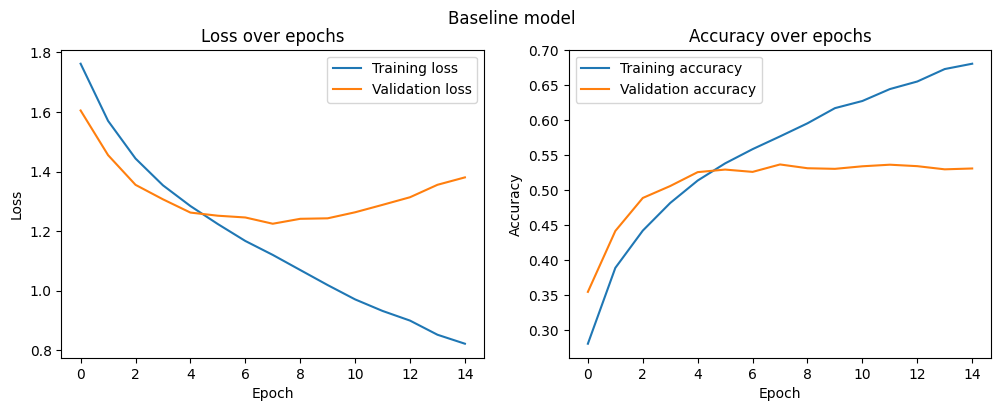

In [12]:
results = []

baseline_model = build_model(
    NUM_CLASSES,
    learning_rate=0.001
)

baseline_history, baseline_result = run_experiment(
    name="Baseline model",
    model=baseline_model,
    epochs=15,
    batch_size=32,
    learning_rate=0.001,
    callbacks=None,
    verbose=0
)

results.append(baseline_result)

För baseline modellen använder jag:
- **learning rate: 0.001**
- **epochs: 15** 
- **batchsize: 32**
- **Dropout: 0.5**

Modellen börjar med att lära sig träningsdatan och bli successivt bättre, men efter några epoker börjar modellen att overfitta, både för **Accuracy** och **Loss** graferna. Med andra ord, modellen blir bättre på träningsbilderna men inte nya bilder, så den börjar memorera träningsdatan istället för att generalisera.

#### **Andra modellen, en förbättrad modell**



Kör experiment: Improved model
epochs=20, batch_size=32, learning_rate=0.0001


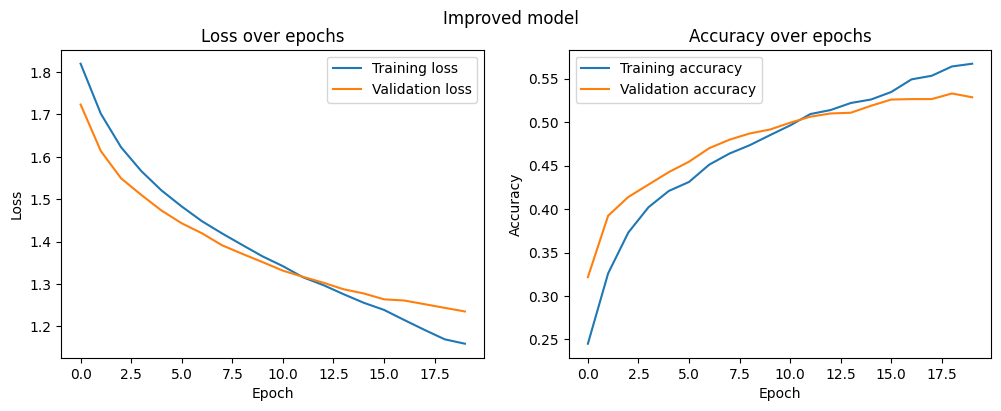

In [13]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

early_stop = keras.callbacks.EarlyStopping(
    monitor  = 'val_loss',
    patience = 5,           
    restore_best_weights = True
)

improved_model = build_model(
    NUM_CLASSES,
    learning_rate=0.0001
)

improved_history, improved_result = run_experiment(
    name="Improved model",
    model=improved_model,
    epochs=20,
    batch_size=32,
    learning_rate=0.0001,
    callbacks=[early_stop],
    verbose=0
)

results.append(improved_result)

För improved modellen använder jag:
- **learning rate: 0.0001**
- **epochs: 20** 
- **batch size: 32**
- **Dropout: 0.5**

 och lade även till early stopping med: 
 - **val_loss**
 - **patience=5**
 - **restore_best_weights=True**.

Man kan se att att den förbättrade modellen ser bättre ut än baseline-modellen. Den generaliserar bättre och overfitting har minskat. Skillnaden mellan train och validation är mindre, vilket visar att den generaliserar bättre till ny data.

## **6. Utvärdera modellen**

In [23]:
results_df = pd.DataFrame(results)
results_df.sort_values("test_accuracy", ascending=False)

#print(results_df.sort_values("test_accuracy", ascending=False).to_string(index=False))

,experiment,epochs,batch_size,learning_rate,test_loss,test_accuracy
1,Improved model,20,32,0.0001,1.222090,0.541655
0,Baseline model,15,32,0.0010,1.375641,0.532321


En tabell över de båda modellerna, där improved är har mindre test_loss och något högre accuracy, vilket gör den till den bästa av de två modellerna. 

#### **Prediktion för alla bilderna i testdatasetet**

In [25]:
# Hämta sanna labels och prediktioner för hela testdatasetet
y_true = []
y_pred = []

y_pred = np.argmax(baseline_model.predict(test_dataset), axis=1)
y_true = np.concatenate([labels.numpy() for _, labels in test_dataset])

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
              precision    recall  f1-score   support

       angry       0.44      0.41      0.43       958
     disgust       0.75      0.16      0.27       111
        fear       0.39      0.28      0.32      1024
       happy       0.76      0.73      0.75      1774
     neutral       0.45      0.56      0.50      1233
         sad       0.38      0.47      0.42      1247
    surprise       0.70      0.66      0.68       831

    accuracy                           0.53      7178
   macro avg       0.55      0.47      0.48      7178
weighted avg       0.54      0.53      0.53      7178



En classification report som visar:
- precision - hur många av en klass som modellen gissade tillhörde rätt klass
- recall - av alla biler av en klass, hur många hittade modellen
- f1-score - en kombination av precision och recall
- accuracy - totalt av alla bilderna, hur många gissade den rätt

I precision kan man se att den lyckas bäst på ```happy```, samt även ```disgust```, dock så hittar den bara ca 18% av bilderna av klassen ```disgust```, vilket kan indikera att den har svårt att tolka det ansiktsuttrycket korrekt, något som stöds av Confusion matrixen nedanför, samt f1-score på bara 29 %. ```happy``` däremot har ett f1-score på 75%.

In [41]:
y_pred_improved = np.argmax(improved_model.predict(test_dataset), axis=1)

print("                    <<< Improved model >>>\n")
print(classification_report(y_true, y_pred_improved, target_names=CLASS_NAMES, zero_division=0))

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
                    <<< Improved model >>>

              precision    recall  f1-score   support

       angry       0.45      0.43      0.44       958
     disgust       0.00      0.00      0.00       111
        fear       0.38      0.28      0.32      1024
       happy       0.74      0.77      0.76      1774
     neutral       0.49      0.55      0.52      1233
         sad       0.40      0.48      0.43      1247
    surprise       0.71      0.66      0.68       831

    accuracy                           0.54      7178
   macro avg       0.45      0.45      0.45      7178
weighted avg       0.53      0.54      0.53      7178



#### **Confusion Matrix**

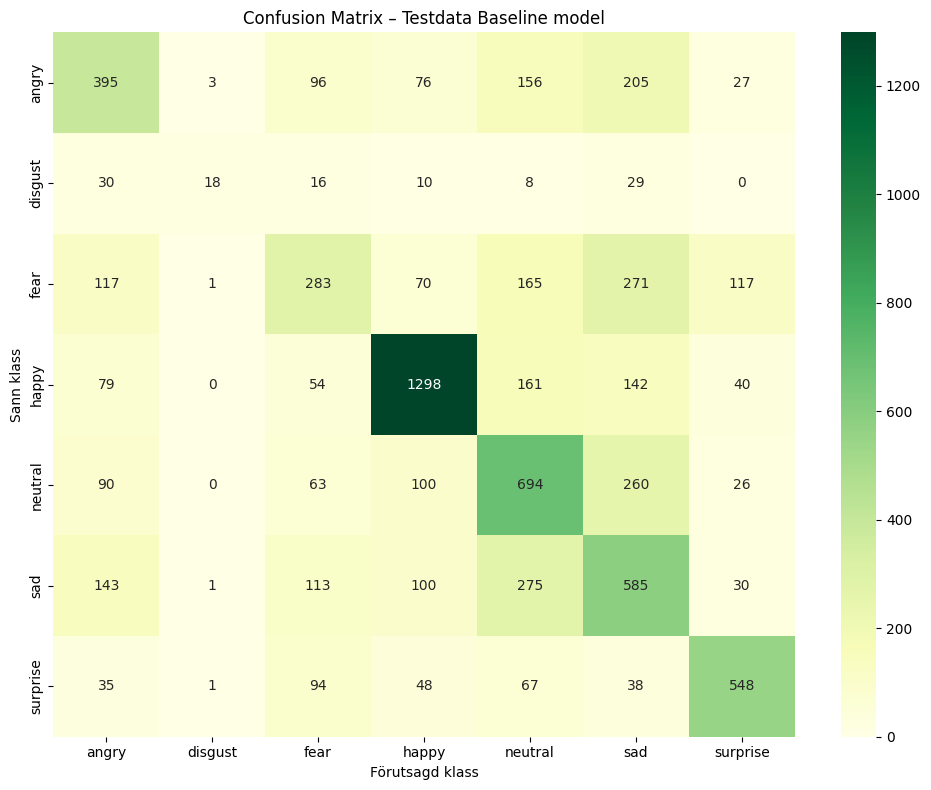

In [29]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGn',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix – Testdata Baseline model')
plt.ylabel('Sann klass')
plt.xlabel('Förutsagd klass')
plt.tight_layout()
plt.show()

Confusion matrixen visar vilka klasser modellen oftare blandar ihop. Då bilderna är svart-vita, små och i vissa fall är ansiktsuttrycken rätt så lika varandra, gör det det svårare för modellen att läsa rätt ansiktsuttryck. 

Modellen har lättare att få rätt på ```happy```, medans den lätt förväxlar ```sad``` med ```neutral```, och ```fear``` med ```sad```.

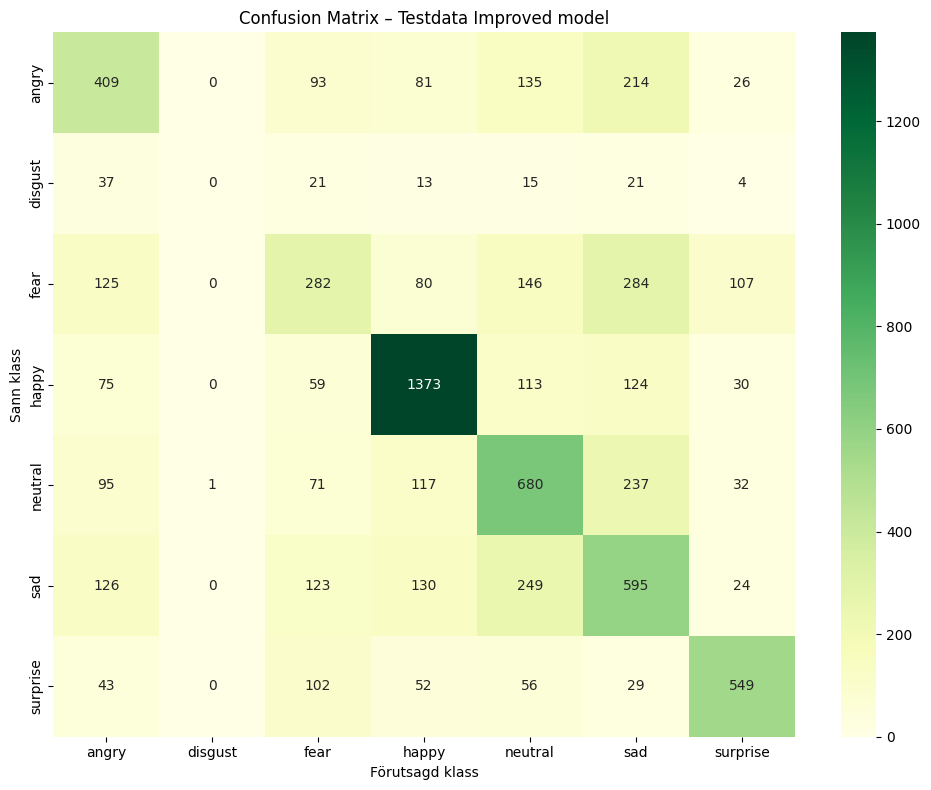

In [28]:
cm2 = confusion_matrix(y_true, y_pred_improved)
plt.figure(figsize=(10, 8))
sns.heatmap(cm2, annot=True, fmt='d', cmap='YlGn',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix – Testdata Improved model')
plt.ylabel('Sann klass')
plt.xlabel('Förutsagd klass')
plt.tight_layout()
plt.show()

## **7. Prediktioner på ny data**

Tar en bild från test-mappen för att göra en prediktion på. Läser in och förbereder bilden på liknande sätt som train och test datan. 

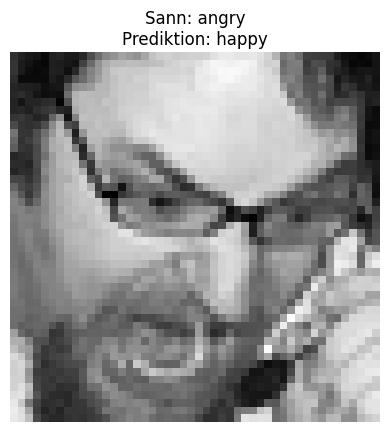

Sann label: angry
Prediktion: happy
Säkerhet: 40.9264

Sannolikheter per klass:
  angry: 11.1%
  disgust: 1.6%
  fear: 6.2%
  happy: 40.9%
  neutral: 19.4%
  sad: 18.5%
  surprise: 2.3%


In [18]:
new_img = CLASS_NAMES[0]
sample_img  = os.path.join(test_path, new_img,
  os.listdir(os.path.join(test_path, new_img))[0])

img = tf.keras.utils.load_img(
    sample_img, color_mode="grayscale",
    target_size=(48, 48))

img_array = tf.keras.utils.img_to_array(img)
img_array = img_array / 255.0
img_array = tf.expand_dims(img_array, 0) 

predictions = improved_model.predict(img_array, verbose=0)
score = predictions[0]
predicted_label = CLASS_NAMES[np.argmax(score)]

plt.imshow(tf.squeeze(img).numpy(), cmap='gray')
plt.title(
    f"Sann: {new_img}\n"
    f"Prediktion: {predicted_label}"
)
plt.axis("off")
plt.show()

print("Sann label:", new_img)
print("Prediktion:", predicted_label)
print("Säkerhet:", 100 * np.max(score))

print('\nSannolikheter per klass:')
for cls, prob in zip(CLASS_NAMES, score):
    print(f'  {cls}: {prob*100:.1f}%')

Använder improved_model att göra en prediktion på. Bildens sanna klass är ```angry```, men enligt modellens prediktion är den ```happy```, med ca 40% säkerhet. Från Confusion matrixen högre upp kan man se att ```angry``` är en klass den har svårare att gissa rätt på. 

Har med en lista över sannolikheter per klass. Högst får ```happy``` med 40,9%, sen ```neutral``` 19.4%, ```sad``` 18.5%, och först på fjärde plats kommer den sanna klassen, ```angry``` med 11.1%.

## **8. Analysera resultatet**

Modellen lyckas rätt så bra med lite över hälften korrekt på test accuracy, vilket även förbättrades då modellen gjordes lite mer avancerad.

Baseline modellen visar tydliga tecken på overfitting, validation accuracy förbättras främst under de första epokerna för att sedan plana ut, och validation loss ökar efter några epoker, ett tydligt tecken på overfitting. 
Improved modellen visar på mindre overfitting, skillanden mellan training accuracy och validation accuracy är mindre, modellen generaliserar bättre. Validation loss fortsätter att minska under större delen av träningen. 

Modellen presterar bättre på träningsdatan än på testdatan. Det betyder att modellen inte generaliserar perfekt till ny data. 

Det som påverkar resultatet mest är faktorer så som:
- antalet convolutional layers
- antal epoker
- regularisering
- mängden träningsdata

De båda modellerna har olika antal epoker, baseline har inte early stopping, men det har improved. Jag testade båda modellerna utan dropout först, och fick då högre overfitting. När jag först tränade båda modellerna med en mindre mängd träningsdata, så blev resultatet lite annorlunda, mer overfitting än när den använder hela datatsetet.

Begränsningar som modellen har är att datasetet är inte balanserat. Till exempel ```disgust``` har mycket mindre antal bilder än resten av klasserna. Bilderna är små, och de är i gråskala, det gör det svårare för modellen att tyda ansiktsyttrycket. Sen är vissa uttryck rätt så lika varandra.

## **9. Reflektion**

Det som var svårast för mig var till att börja med att läsa in datan och hur man förbereder den för användning, hur man gör när den datan redan är uppdelad som den är i test och train med labels etc. Sen att testa olika kombinationer för modellen att se hur man kunde få en som inte overfittade för mycket.

Jag lärde mig att skapa en CNN modell, hur viktigt regularisering är och hur mycket det påverkar en modell. Hur man tränar och utvärderar neurala nätverk. Hur man avläser overfitting med hjälp av grafer. 

Om jag hade börjat om så hade jag velat testa fler hyperparametrar, experimentera med regularisering. Kanske inte tagit med klassen ```disgust``` för att minska obalansen i datatsetet. 

Jag tycker mitt arbete motsvarar i alla fall G, då jag byggt en fungerande modell, tränat och utvärderat den, gjort prediktion på ny data samt gjort en analys av resultatet. Sen har jag även gjort arbete som motsvarar VG kraven: jag har gjort en extra modell och jämfört dem, förbättrat modellen, gjort en djupare analys. 